In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)


In [2]:
df = pd.read_csv('archive/loan_approval_dataset.csv')
df.columns = df.columns.str.strip()
df.drop(columns=['loan_id'], errors='ignore', inplace=True)

cat_cols_all = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
df[cat_cols_all] = df[cat_cols_all].apply(lambda col: col.astype(str).str.strip().str.lower())

In [3]:
# Classification — predict approved/rejected
# X includes loan_amount because the bank sees the requested amount at decision time
X_clf = df.drop(columns=['loan_status'])
y_clf = (df['loan_status'] == 'approved').astype(int)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print('Classification — Train:', X_clf_train.shape, '| Test:', X_clf_test.shape)
print('Class balance (train):', y_clf_train.value_counts().to_dict())


Classification — Train: (3415, 11) | Test: (854, 11)
Class balance (train): {1: 2125, 0: 1290}


In [4]:
# Regression — predict loan amount, trained only on approved loans
approved_df = df[df['loan_status'] == 'approved'].copy()

X_reg = approved_df.drop(columns=['loan_status', 'loan_amount'])
y_reg = approved_df['loan_amount']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print('Regression — Train:', X_reg_train.shape, '| Test:', X_reg_test.shape)
print('Target (loan_amount) stats:')
print(y_reg.describe())

Regression — Train: (2124, 10) | Test: (532, 10)
Target (loan_amount) stats:
count    2.656000e+03
mean     1.524725e+07
std      9.221696e+06
min      3.000000e+05
25%      7.500000e+06
50%      1.460000e+07
75%      2.210000e+07
max      3.950000e+07
Name: loan_amount, dtype: float64


In [5]:
cat_cols = X_clf_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
num_cols = X_clf_train.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical:', cat_cols)
print('Numerical:  ', num_cols)

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')


Categorical: ['education', 'self_employed']
Numerical:   ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

clf_results = []

for name, model in classifiers.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_clf_train, y_clf_train)
    y_pred = pipeline.predict(X_clf_test)
    clf_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_clf_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_clf_test, y_pred), 4),
    })

clf_results_df = pd.DataFrame(clf_results).sort_values('F1 Score', ascending=False)
clf_results_df

,Model,Accuracy,F1 Score
3,Gradient Boosting,0.9824,0.9859
2,Random Forest,0.9801,0.9840
4,XGBoost,0.9801,0.9840
1,Decision Tree,0.9789,0.9831
0,Logistic Regression,0.9145,0.9321


In [7]:
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
best_pipeline.fit(X_clf_train, y_clf_train)
print(classification_report(y_clf_test, best_pipeline.predict(X_clf_test),
                            target_names=['rejected', 'approved']))


              precision    recall  f1-score   support

    rejected       0.98      0.97      0.98       323
    approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

cat_cols_reg = X_reg_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
num_cols_reg = X_reg_train.select_dtypes(include=[np.number]).columns.tolist()

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_reg),
    ('cat', categorical_transformer, cat_cols_reg)
], remainder='drop')

regressors = {
    'Linear Regression':    LinearRegression(),
    'Ridge':                Ridge(),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'Random Forest':        RandomForestRegressor(random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(random_state=42),
    'XGBoost':              XGBRegressor(random_state=42)
}

reg_results = []

for name, model in regressors.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_reg_train, y_reg_train)
    y_pred = pipeline.predict(X_reg_test)
    reg_results.append({
        'Model': name,
        'R²':    round(r2_score(y_reg_test, y_pred), 4),
        'MAE':   round(mean_absolute_error(y_reg_test, y_pred), 0),
        'RMSE':  round(mean_squared_error(y_reg_test, y_pred) ** 0.5, 0),
    })

reg_results_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False)
reg_results_df


,Model,R²,MAE,RMSE
4,Gradient Boosting,0.8792,2426494.0,3222215.0
0,Linear Regression,0.8727,2504399.0,3308121.0
1,Ridge,0.8727,2504177.0,3308101.0
3,Random Forest,0.8691,2484594.0,3354445.0
5,XGBoost,0.8495,2608785.0,3597108.0
2,Decision Tree,0.7467,3325940.0,4666301.0


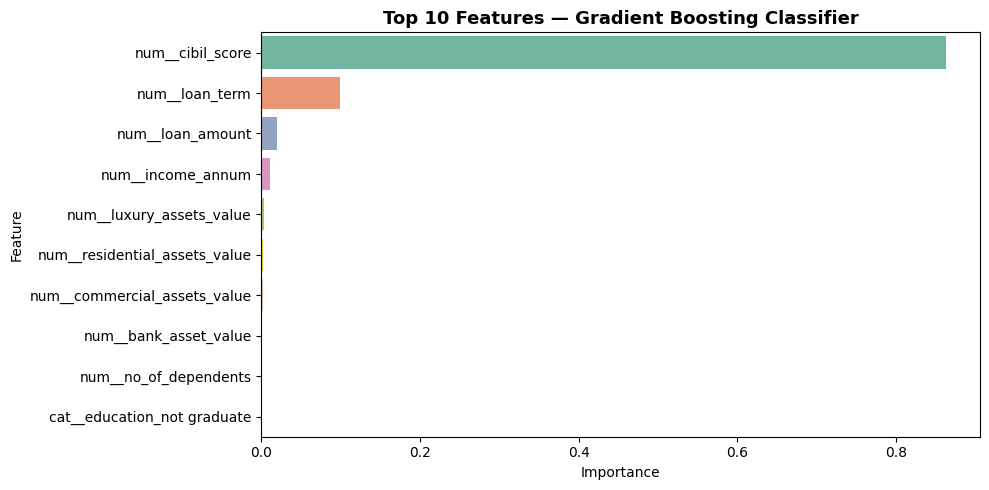

In [9]:
from sklearn.inspection import permutation_importance

# refit best classifier
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])
clf_pipeline.fit(X_clf_train, y_clf_train)

feature_names = clf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = clf_pipeline.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='Set2')
plt.title('Top 10 Features — Gradient Boosting Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


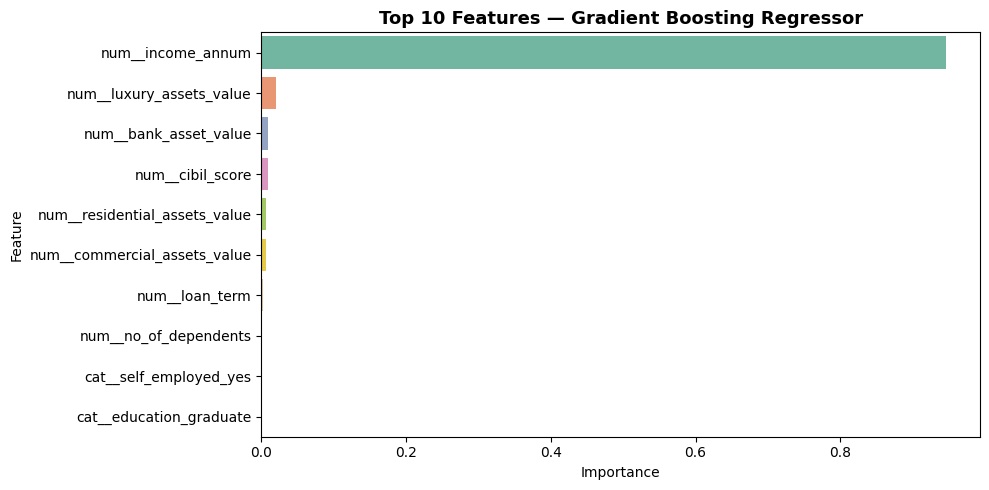

In [10]:
reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
reg_pipeline.fit(X_reg_train, y_reg_train)

reg_feature_names = reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
reg_importances = reg_pipeline.named_steps['model'].feature_importances_

reg_imp_df = pd.DataFrame({'Feature': reg_feature_names, 'Importance': reg_importances})
reg_imp_df = reg_imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=reg_imp_df, x='Importance', y='Feature', palette='Set2')
plt.title('Top 10 Features — Gradient Boosting Regressor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Summary

### Model Selection

| Task | Winner | Key Metric |
|---|---|---|
| Classification (Approved/Rejected) | Gradient Boosting | F1: 0.986 |
| Regression (Loan Amount) | Gradient Boosting | R²: 0.879, MAE: ~2.4M |

### Key Findings

**Classification**
- All tree-based models performed near-identically (~0.983–0.986 F1) — the CIBIL threshold makes this an almost deterministic problem
- Logistic Regression underperformed (F1: 0.932) — confirms the decision boundary is non-linear
- CIBIL score dominates feature importance by a large margin

**Regression**
- Linear models (R²: 0.873) were surprisingly competitive with Gradient Boosting (R²: 0.879) — the loan amount relationship is largely driven by income, which is near-linear
- Scatter plots revealed heteroscedasticity (fan shape) — variance grows with income, which slightly penalises linear models
- Income and luxury assets are the dominant predictors

### Next Steps
- Take both Gradient Boosting models into `3_Modeling.ipynb`
- Tune hyperparameters via GridSearchCV
- Save final pipelines as `.pkl` artifacts